In [1]:
from IPython.display import Image, display

# Ordenação topológica
- Organizar os nós de um grafo como se fosse um array
- Usado para ordem de prioridade quando temos uma tarefa que exige ser feita antes da outra
- Necessariamente o grafo precisa ser DAG

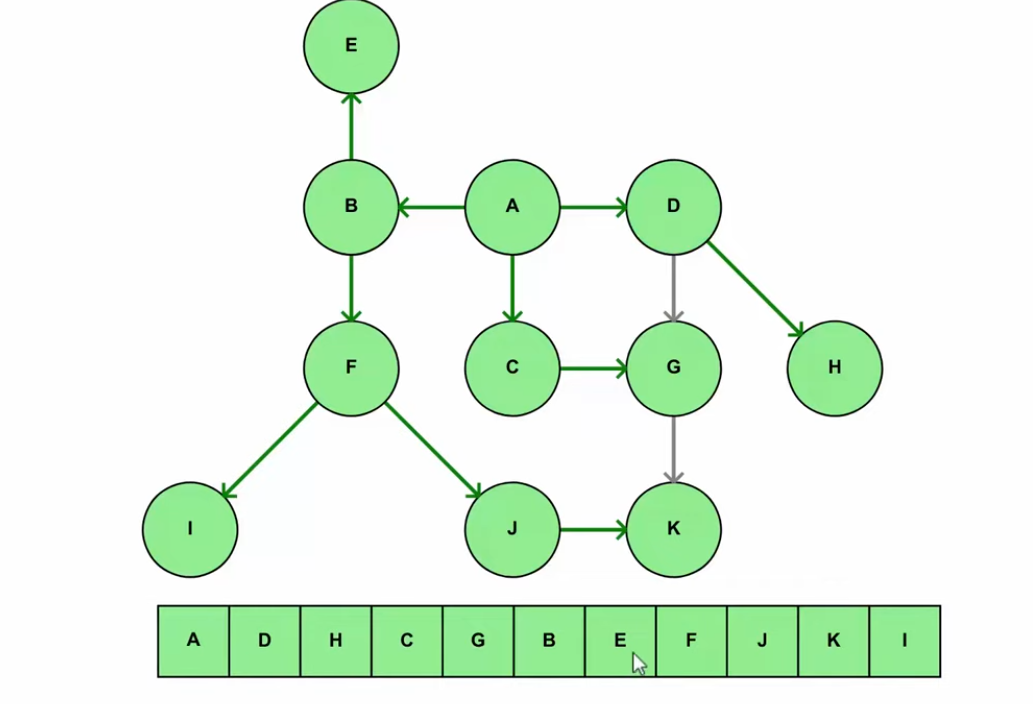

In [5]:
display(Image(filename='image.png', width = 400))

# Algoritmos
- DFS -> Basta ir andando no DFS até chegar no ultimo cara, quando chegar basta colocar ele no final da fila (pensei em colocar isso depois do for que tem sempre no dfs), não precisa começar de nenhum vertice especifico
- BFS Algoritmo de kahn:
1. Contar qual o grau de entrada de cada vertice
2. Colocar todos os vertices de g-in = 0 na fila (g-in = grau de entrada)
3. Enquanto existir a fila voce vai:  
    4. Remover um nó da fila e adicionar na nossa lista de resposta  
    5. Para cada vizinho:  
&emsp; 6. Remove um do grau de entrada  
&emsp; 7. Se o grau chegar em 0, adicione ele na fila  
- Em 90% dos casos, é melhor usar BFS, pois é mais simples. DFS só seria util se o problema pedir, por exemplo, todas as ordenações topológicas.

In [ ]:
from collections import deque, defaultdict
'''LeetCode 207 - Course Schedule'''
def canFinish(numCourses, prerequisites):
    # 1. Construir o grafo (Lista de adjacência) e o array de graus de entrada (in-degree)
    adj = defaultdict(list)
    in_degree = [0] * numCourses
    
    for course, pre in prerequisites:
        adj[pre].append(course) # A aresta vai do pré-requisito para o curso
        in_degree[course] += 1  # O curso ganha um grau de entrada
        
    # 2. Encontrar todos os nós com in-degree 0 (cursos sem pré-requisitos)
    queue = deque()
    for i in range(numCourses):
        if in_degree[i] == 0:
            queue.append(i)
            
    # 3. Processar a fila (Algoritmo de Kahn)
    courses_taken = 0
    
    while queue:
        current = queue.popleft()
        courses_taken += 1
        
        # Reduzir o in-degree dos cursos que dependiam do atual
        for neighbor in adj[current]:
            in_degree[neighbor] -= 1
            # Se todas as dependências foram resolvidas, adiciona à fila
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
                
    # 4. Verificação final
    # Se conseguimos fazer todos os cursos, não havia ciclos
    return courses_taken == numCourses